**Challenge Telecom X: análisis de evasión de clientes - Parte 2**

In [1]:
import pandas as pd
import numpy as np
url="df_clean.csv"
df=pd.read_csv(url)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_label
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667,0
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,0
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,1
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,1


In [2]:
for col in df.columns:
   print(f"Valores unicos para la columna {col}:")
   print(df[col].unique())
   print("-"*80)

Valores unicos para la columna customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------------------------------------------------------------------
Valores unicos para la columna Churn:
[0 1]
--------------------------------------------------------------------------------
Valores unicos para la columna customer.gender:
['Female' 'Male']
--------------------------------------------------------------------------------
Valores unicos para la columna customer.SeniorCitizen:
[0 1]
--------------------------------------------------------------------------------
Valores unicos para la columna customer.Partner:
[1 0]
--------------------------------------------------------------------------------
Valores unicos para la columna customer.Dependents:
[1 0]
--------------------------------------------------------------------------------
Valores unicos para la columna customer.tenure:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55

In [3]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias',
       'Churn_label'],
      dtype='object')

In [8]:
# Crear copia del df original
df_limpio = df.copy()

# Eliminar Columna no relevante para el analisis
df_limpio = df_limpio.drop(columns=['customerID'])
df_limpio.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_label
0,0,Female,0,1,1,9,1,0,DSL,0,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667,0
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,0
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,1
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,1
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,1


In [28]:
df_limpio.dtypes

,0
Churn,int64
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,int64
customer.Dependents,int64
customer.tenure,int64
phone.PhoneService,int64
phone.MultipleLines,int64
internet.InternetService,object
internet.OnlineSecurity,int64


In [14]:
print(df.columns)

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias',
       'Churn_label'],
      dtype='object')


In [18]:
# Agrupar "No internet service" como "No"
columnas_internet = [
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies'
]

for col in columnas_internet:
    df_limpio[col] = df_limpio[col].replace('No internet service', 'No')


# Agrupar "No phone service" como "No"
columnas_telefono = [
    'phone.MultipleLines'
]

for col in columnas_telefono:
    df_limpio[col] = df_limpio[col].replace('No phone service', 'No')



In [22]:
# Ver columnas categóricas
categoricas = df.select_dtypes(include='object').columns.tolist()
categoricas


['customerID',
 'customer.gender',
 'internet.InternetService',
 'account.Contract',
 'account.PaymentMethod']

In [23]:
df_modelo = df.drop(columns=['customerID'])

Aplicar One-Hot Encoding con pandas

In [25]:
df_encoded = pd.get_dummies(
    df_modelo,
    columns=df_modelo.select_dtypes(include='object').columns,
    drop_first=True
)

Convertir booleanos a 0 y 1

In [26]:
df_encoded = df_encoded.apply(
    lambda x: x.astype(int) if x.dtype == 'bool' else x
)

In [27]:
df_encoded.dtypes

,0
Churn,int64
customer.SeniorCitizen,int64
customer.Partner,int64
customer.Dependents,int64
customer.tenure,int64
phone.PhoneService,int64
phone.MultipleLines,int64
internet.OnlineSecurity,int64
internet.OnlineBackup,int64
internet.DeviceProtection,int64


In [30]:
df_encoded.head()

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,...,Cuentas_Diarias,Churn_label,customer.gender_Male,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,2.186667,0,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,1.996667,0,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,2.463333,1,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,3.266667,1,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,2.796667,1,0,1,0,0,0,0,0,1


In [29]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7043 non-null   int64  
 1   customer.SeniorCitizen                         7043 non-null   int64  
 2   customer.Partner                               7043 non-null   int64  
 3   customer.Dependents                            7043 non-null   int64  
 4   customer.tenure                                7043 non-null   int64  
 5   phone.PhoneService                             7043 non-null   int64  
 6   phone.MultipleLines                            7043 non-null   int64  
 7   internet.OnlineSecurity                        7043 non-null   int64  
 8   internet.OnlineBackup                          7043 non-null   int64  
 9   internet.DeviceProtection                      7043 

In [31]:
df['Churn_label'].value_counts()
df['Churn_label'].value_counts(normalize=True) * 100
resumen = pd.DataFrame({
    'Cantidad': df['Churn_label'].value_counts(),
    'Proporcion (%)': df['Churn_label'].value_counts(normalize=True) * 100
})

resumen


,Cantidad,Proporcion (%)
Churn_label,,
0,5174,73.463013
1,1869,26.536987


In [35]:
!pip install imbalanced-learn

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

X = df_encoded.drop("Churn_label", axis=1)
y = df_encoded["Churn_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("Antes de SMOTE:")
print(y_train.value_counts())

print("\nDespués de SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Antes de SMOTE:
Churn_label
0    4139
1    1495
Name: count, dtype: int64

Después de SMOTE:
Churn_label
0    4139
1    4139
Name: count, dtype: int64


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustar SOLO en entrenamiento
X_train_scaled = scaler.fit_transform(X_train_smote)

# Transformar test con los mismos parámetros
X_test_scaled = scaler.transform(X_test)

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Usamos el dataframe codificado
corr_matrix = df_encoded.corr()

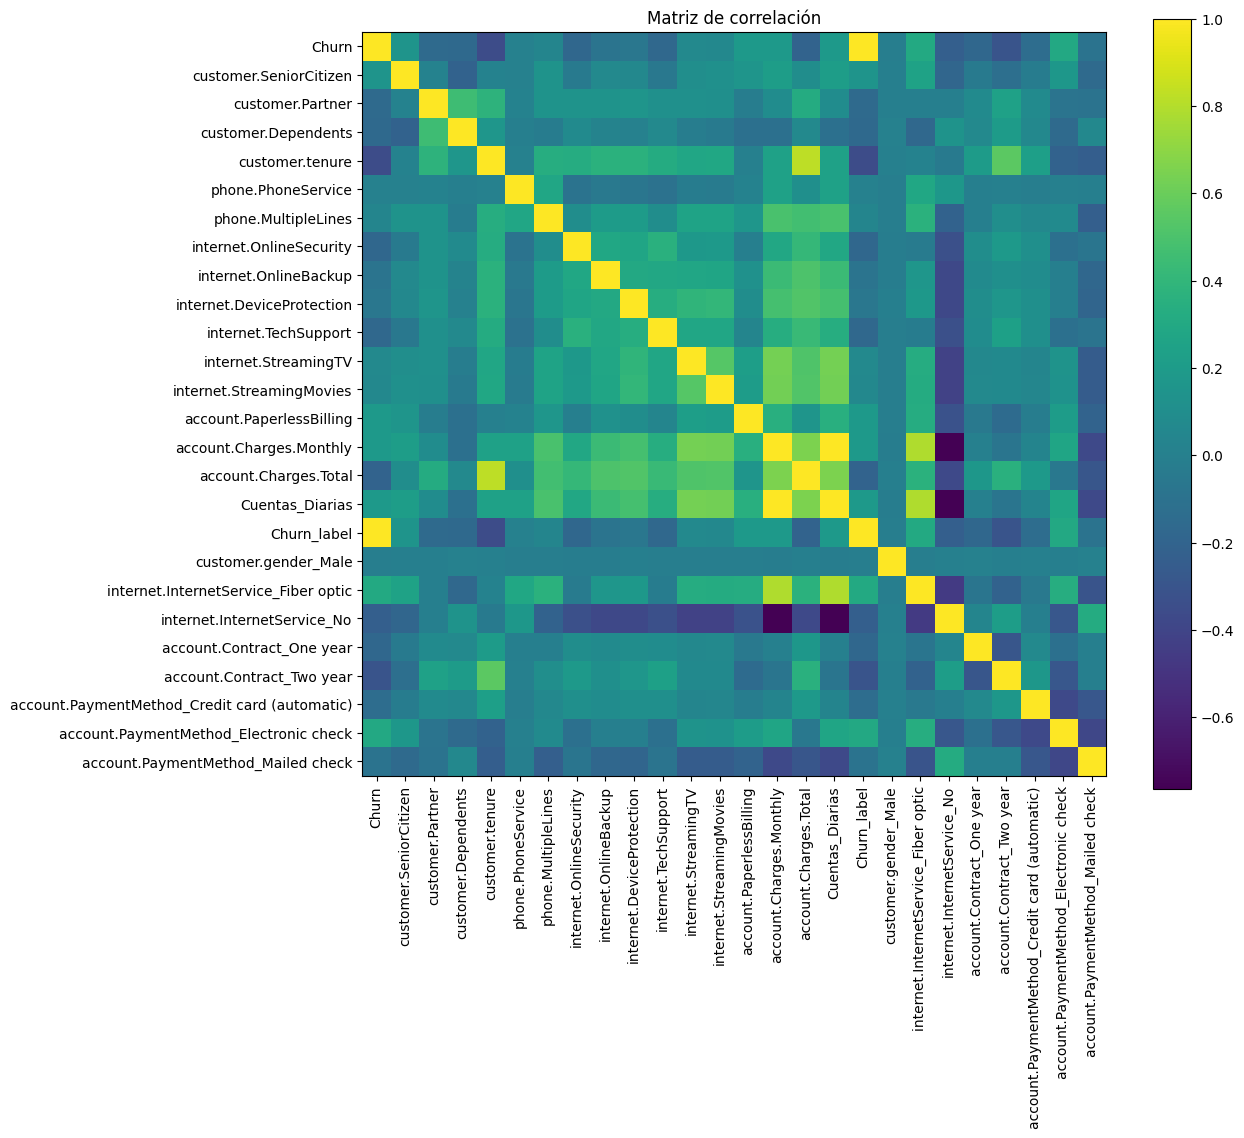

In [52]:
plt.figure(figsize=(12,10))
plt.imshow(corr_matrix)
plt.colorbar()
plt.title("Matriz de correlación")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show()

In [53]:
corr_churn = corr_matrix["Churn_label"].sort_values(ascending=False)

corr_churn.head(10)

,Churn_label
Churn,1.000000
Churn_label,1.000000
internet.InternetService_Fiber optic,0.308020
account.PaymentMethod_Electronic check,0.301919
account.Charges.Monthly,0.193356
Cuentas_Diarias,0.193356
account.PaperlessBilling,0.191825
customer.SeniorCitizen,0.150889
internet.StreamingTV,0.063228
internet.StreamingMovies,0.061382


In [54]:
corr_churn.tail(10)

,Churn_label
account.PaymentMethod_Credit card (automatic),-0.134302
customer.Partner,-0.150448
customer.Dependents,-0.164221
internet.TechSupport,-0.164674
internet.OnlineSecurity,-0.171226
account.Contract_One year,-0.177820
account.Charges.Total,-0.199484
internet.InternetService_No,-0.227890
account.Contract_Two year,-0.302253
customer.tenure,-0.352229


In [61]:
df.head()

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,...,Cuentas_Diarias,Churn_label,customer.gender_Male,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,2.186667,0,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,1.996667,0,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,2.463333,1,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,3.266667,1,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,2.796667,1,0,1,0,0,0,0,0,1


<Figure size 800x600 with 0 Axes>

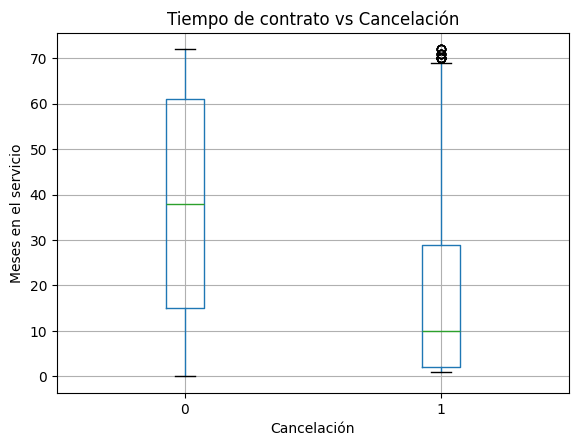

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
df.boxplot(column="customer.tenure", by="Churn")
plt.title("Tiempo de contrato vs Cancelación")
plt.suptitle("")
plt.xlabel("Cancelación")
plt.ylabel("Meses en el servicio")
plt.show()

<Figure size 800x600 with 0 Axes>

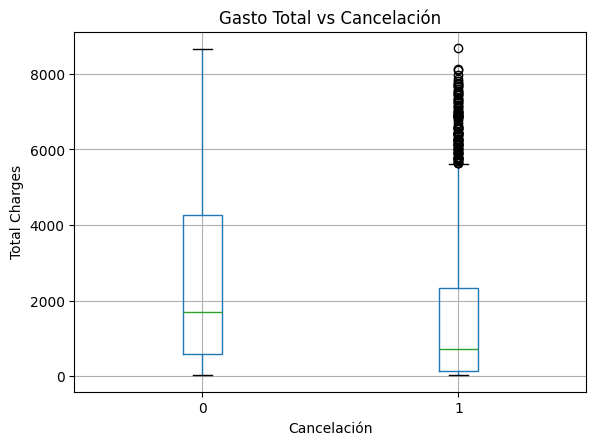

In [69]:
plt.figure(figsize=(8,6))
df.boxplot(column="account.Charges.Total", by="Churn")
plt.title("Gasto Total vs Cancelación")
plt.suptitle("")
plt.xlabel("Cancelación")
plt.ylabel("Total Charges")
plt.show()

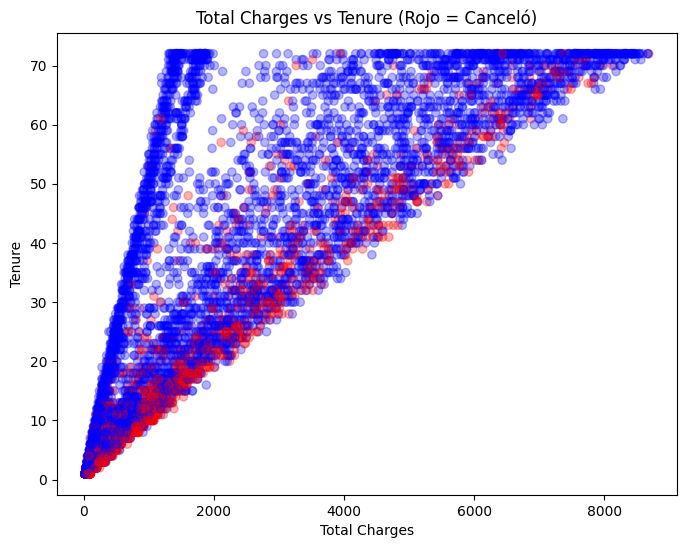

In [78]:
plt.figure(figsize=(8,6))

colors = df["Churn"].map({0: "blue", 1: "red"})

plt.scatter(
    df["account.Charges.Total"],
    df["customer.tenure"],
    c=colors,
    alpha=0.3
)

plt.xlabel("Total Charges")
plt.ylabel("Tenure")
plt.title("Total Charges vs Tenure (Rojo = Canceló)")
plt.show()

In [80]:
from sklearn.model_selection import train_test_split

# X = variables predictoras
X = df_encoded.drop("Churn", axis=1)

# y = variable objetivo
y = df_encoded["Churn"]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% prueba
    random_state=42,      # reproducibilidad
    stratify=y            # mantiene proporción de clases
)

In [83]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5634, 25)
Prueba: (1409, 25)


In [84]:
print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Distribución en entrenamiento:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Distribución en prueba:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


Creación de Modelos

In [117]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["Churn", "Churn_label"])
y = df_encoded["Churn_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

MODELO 1 — Regresión Logística (CON normalización)

In [118]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


In [119]:
import numpy as np
print("NaN después de imputar:", np.isnan(X_train_imputed).sum())

NaN después de imputar: 0


In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [121]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [122]:
print(np.isnan(X_train_scaled).sum())

0


In [123]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predicciones
y_pred_log = log_model.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_log))

# Reporte completo
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_log))

# Matriz de confusión
print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.7927608232789212

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Matriz de confusión:

[[922 113]
 [179 195]]


**Random Forest**
La Regresión Logística requiere normalización porque es sensible a la escala de las variables.
Random Forest no requiere normalización ya que basa sus decisiones en reglas de división y no en distancias o magnitudes absolutas

In [124]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Crear modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Entrenar (SIN escalado)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf))
print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7892122072391767

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409


Matriz de confusión:

[[935 100]
 [197 177]]


In [126]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("MODELO 1 — REGRESIÓN LOGÍSTICA\n")

# Predicciones
y_pred_log = log_model.predict(X_test_scaled)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nReporte completo:\n")
print(classification_report(y_test, y_pred_log))

print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, y_pred_log))

MODELO 1 — REGRESIÓN LOGÍSTICA

Accuracy: 0.7927608232789212
Precision: 0.6331168831168831
Recall: 0.5213903743315508
F1-score: 0.5718475073313783

Reporte completo:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Matriz de confusión:

[[922 113]
 [179 195]]


Interpretación:

922 → Correctamente clasificados como no cancelan

113 → Falsos positivos (predijo cancelación pero no cancelaron)

179 → Falsos negativos (cancelaron pero no los detectó)

195 → Verdaderos positivos (cancelaron y los detectó)

In [127]:
print("MODELO 2 — RANDOM FOREST\n")

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nReporte completo:\n")
print(classification_report(y_test, y_pred_rf))

print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, y_pred_rf))

MODELO 2 — RANDOM FOREST

Accuracy: 0.7892122072391767
Precision: 0.6389891696750902
Recall: 0.4732620320855615
F1-score: 0.543778801843318

Reporte completo:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409


Matriz de confusión:

[[935 100]
 [197 177]]


Ambos modelos presentan un desempeño similar en términos de exactitud general (~79%). Sin embargo, la Regresión Logística mostró un mejor equilibrio entre precisión y recall en la detección de clientes que cancelan, logrando un mayor F1-score (0.57 vs 0.54).

El Random Forest, a pesar de ser un modelo más complejo, no superó el rendimiento del modelo lineal en este caso. Esto sugiere que las relaciones en los datos pueden ser mayormente lineales o que el modelo de bosque aleatorio requiere ajuste adicional de hiperparámetros para mejorar su desempeño.

In [128]:
print("REGRESIÓN LOGÍSTICA")
print("Train accuracy:", log_model.score(X_train_scaled, y_train))
print("Test accuracy:", log_model.score(X_test_scaled, y_test))

print("\nRANDOM FOREST")
print("Train accuracy:", rf_model.score(X_train, y_train))
print("Test accuracy:", rf_model.score(X_test, y_test))

REGRESIÓN LOGÍSTICA
Train accuracy: 0.8104366347177849
Test accuracy: 0.7927608232789212

RANDOM FOREST
Train accuracy: 0.9976925807596734
Test accuracy: 0.7892122072391767


Regresión Logística: Coeficientes

In [130]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes["Abs"] = coeficientes["Coeficiente"].abs()

coeficientes = coeficientes.sort_values(by="Abs", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente,Abs
3,customer.tenure,-1.406935,1.406935
14,account.Charges.Total,0.676495,0.676495
20,account.Contract_Two year,-0.583950,0.583950
17,internet.InternetService_Fiber optic,0.571506,0.571506
18,internet.InternetService_No,-0.515207,0.515207
19,account.Contract_One year,-0.280103,0.280103
15,Cuentas_Diarias,-0.266209,0.266209
13,account.Charges.Monthly,-0.266209,0.266209
10,internet.StreamingTV,0.195802,0.195802
5,phone.MultipleLines,0.193676,0.193676


Random Forest: Importancia de Variables

In [129]:
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importancia", ascending=False)

importances.head(10)

,Variable,Importancia
14,account.Charges.Total,0.170174
3,customer.tenure,0.151956
13,account.Charges.Monthly,0.136060
15,Cuentas_Diarias,0.135354
20,account.Contract_Two year,0.037340
22,account.PaymentMethod_Electronic check,0.036280
17,internet.InternetService_Fiber optic,0.033205
16,customer.gender_Male,0.024964
12,account.PaperlessBilling,0.024090
19,account.Contract_One year,0.023725


📊 Informe de Análisis de Cancelación de Clientes (Churn)
1️⃣ Objetivo del análisis

El objetivo del proyecto fue identificar los factores que influyen en la cancelación de clientes y construir modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de abandonar el servicio.

Se trabajó con dos modelos:

Regresión Logística (con normalización)

Random Forest (sin normalización)


2️⃣ Rendimiento de los Modelos

🔹 Regresión Logística

Exactitud: 79%

Recall (cancelación): 52%

F1-score: 0.57

El modelo logra clasificar correctamente la mayoría de los clientes. Sin embargo, solo detecta aproximadamente la mitad de los clientes que realmente cancelan.

🔹 Random Forest

Exactitud: 79%

Recall (cancelación): 47%

F1-score: 0.54

El rendimiento fue muy similar al modelo anterior, pero con menor capacidad para detectar clientes que cancelan.

📌 Comparación general

Ambos modelos tuvieron un desempeño parecido en términos de exactitud. Sin embargo, la Regresión Logística mostró un mejor equilibrio en la detección de cancelaciones.

Ninguno de los modelos presentó señales graves de sobreajuste (overfitting), ya que su rendimiento fue consistente entre entrenamiento y prueba.


3️⃣ Principales Factores que Influyen en la Cancelación

Del análisis de los coeficientes y la importancia de variables, se identificaron como factores más influyentes:

🔹 Tipo de contrato

Los clientes con contrato mensual presentan mayor probabilidad de cancelar.

Esto sugiere que la falta de compromiso a largo plazo facilita la decisión de abandonar el servicio.

🔹 Tiempo de permanencia (tenure)

Los clientes con menor antigüedad tienen mayor probabilidad de cancelar.

A medida que aumenta el tiempo como cliente, la probabilidad de cancelación disminuye.

Esto indica que la fidelización ocurre con el tiempo.

🔹 Cargos mensuales

Clientes con cargos mensuales más altos tienden a cancelar con mayor frecuencia.

El precio percibido parece influir en la decisión de abandono.

🔹 Servicios adicionales

Servicios como soporte técnico, seguridad en línea o protección de dispositivos influyen en la permanencia.

Los clientes con más servicios contratados tienden a quedarse más tiempo.


4️⃣ Principales Factores de Riesgo


En resumen, el perfil con mayor riesgo de cancelación es:

Cliente nuevo

Con contrato mensual

Con cargos mensuales altos

Con pocos servicios adicionales contratados


5️⃣ Estrategias de Retención Propuestas


Basándonos en los resultados, se proponen las siguientes acciones:

✅ 1. Incentivar contratos a largo plazo

Ofrecer descuentos o beneficios a clientes con contrato mensual para que migren a planes anuales.

✅ 2. Estrategias para clientes nuevos

Implementar programas de bienvenida y seguimiento durante los primeros meses, que es cuando el riesgo es mayor.

✅ 3. Revisión de estructura de precios

Evaluar si los cargos mensuales están generando percepción de alto costo frente al valor ofrecido.

✅ 4. Promoción de servicios adicionales

Ofrecer paquetes que incluyan soporte técnico o seguridad digital, ya que estos aumentan la permanencia.

✅ 5. Sistema de alerta temprana

Utilizar el modelo predictivo para identificar clientes con alta probabilidad de cancelar y aplicar campañas preventivas.

6️⃣ Conclusión General

El análisis mostró que la cancelación de clientes está fuertemente relacionada con el tipo de contrato, la antigüedad y el nivel de gasto mensual.

Aunque los modelos no alcanzan una detección perfecta, sí permiten identificar patrones claros de riesgo. La Regresión Logística presentó un desempeño ligeramente superior al Random Forest en este caso.

La implementación de estrategias enfocadas en fidelización temprana, contratos de mayor duración y mejora en la percepción de valor puede reducir significativamente la tasa de cancelación.